# Part A - Data Loading and Preprocessing with Scikit-learn

## Task 1 - Load and Understand the Dataset

In [1]:
## Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [24]:
##  Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

df = pd.read_csv('hotel_bookings.csv')
print("****Head****")
print(df.head())
print("\n****Shape****")
print(df.shape)
print("\n****Info****")
df.info()
print("\n****Describe****")
print(df.describe())
print("\n****Datatypes****")
print(df.dtypes)

****Head****
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Depo

In [3]:
## Check the class distribution of is_canceled and use it as the target y.

print(df['is_canceled'].value_counts(normalize=True))
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


In [4]:
## Create X from the remaining usable features. Identify numerical and categorical columns.

numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print(f"Numerical columns count: {len(numerical_cols), (numerical_cols)}")
print(f"Categorical columns count: {len(categorical_cols), (categorical_cols)}")

Numerical columns count: (19, ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests'])
Categorical columns count: (12, ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date'])


## Task 2 - Missing Values, Leakage, and Outliers

In [5]:
## Find the missing-value count and percentage for every column.

missing_count = X.isnull().sum()
missing_percentage = (missing_count / len(X)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percentage})
print(f"Missing Values Summary:\n {missing_df[missing_df['Missing Count'] > 0]}")

Missing Values Summary:
           Missing Count  Percentage (%)
children              4        0.003350
country             488        0.408744
agent             16340       13.686238
company          112593       94.306893


In [6]:
## Identify columns with very high missingness. 

high_missing_cols = [col for col, pct in missing_percentage.items() if pct > 40]

## Drop them only if justified and state the reason.
print(f"Dropping columns with high missingness (>40%): {high_missing_cols}")
X = X.drop(columns=high_missing_cols, errors="ignore")



Dropping columns with high missingness (>40%): ['company']


In [7]:
## Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

leakage_cols = ['reservation_status', 'reservation_status_date']
print(f"Dropping leakage columns: {leakage_cols}")
X = X.drop(columns=[col for col in leakage_cols if col in X.columns])

Dropping leakage columns: ['reservation_status', 'reservation_status_date']


In [8]:
## Check selected numerical features for outliers using boxplots and/or the IQR method.

initial_row_count = len(X)
outlier_cols = ['lead_time', 'adr']
for col in outlier_cols:
    if col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)
        X = X[mask]
        y = y[mask]

In [9]:
## Remove only clear/extreme outliers and report how many rows were removed.

rows_removed = initial_row_count - len(X)
print(f"Extreme outliers removed using IQR, ows removed: {rows_removed}")

Extreme outliers removed using IQR, ows removed: 6773


## Task 3 - Create Two Preprocessing Pipelines

In [10]:
## Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
## For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
## For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
## Pipeline A: KNNImputer + StandardScaler for numerical features.

num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [13]:
## Pipeline B: KNNImputer + MinMaxScaler for numerical features.

num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

In [14]:
## Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_transformer_A, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_transformer_B, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])


# Part B - Model Training and Performance Evaluation

## Task 4 - Train Two Classification Models

In [15]:
## Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.
## Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

models = {
    'Logistic Regression (Pipeline A)': Pipeline(steps=[
        ('preprocessor', preprocessor_A), 
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'Logistic Regression (Pipeline B)': Pipeline(steps=[
        ('preprocessor', preprocessor_B), 
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree (Pipeline A)': Pipeline(steps=[
        ('preprocessor', preprocessor_A), 
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Decision Tree (Pipeline B)': Pipeline(steps=[
        ('preprocessor', preprocessor_B), 
        ('model', DecisionTreeClassifier(random_state=42))
    ])
}

In [16]:
## Keep the model settings and train-test split unchanged across the comparison.
## You should obtain four trained model-pipeline combinations in total.

trained_models = {}
for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

print("\nAll four model-pipeline combinations successfully trained!")

Training Logistic Regression (Pipeline A)...
Training Logistic Regression (Pipeline B)...
Training Decision Tree (Pipeline A)...
Training Decision Tree (Pipeline B)...

All four model-pipeline combinations successfully trained!


## Task 5 - Evaluate and Compare the Four Results

In [17]:
## For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

results = []
for name, pipeline in trained_models.items():
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    
    results.append({
        'Model-Pipeline': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })


In [19]:
## Create a final comparison table containing all four model-pipeline combinations.

comparison_table = pd.DataFrame(results)
print("Final Comparison Table:")
print(comparison_table.to_string(index=False))

Final Comparison Table:
                  Model-Pipeline  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score
Logistic Regression (Pipeline A)        0.815735       0.817972   0.809852 0.649491  0.720861
Logistic Regression (Pipeline B)        0.811572       0.814420   0.807210 0.640044  0.713973
      Decision Tree (Pipeline A)        0.995838       0.859572   0.803259 0.810453  0.806840
      Decision Tree (Pipeline B)        0.995838       0.859528   0.803309 0.810207  0.806743


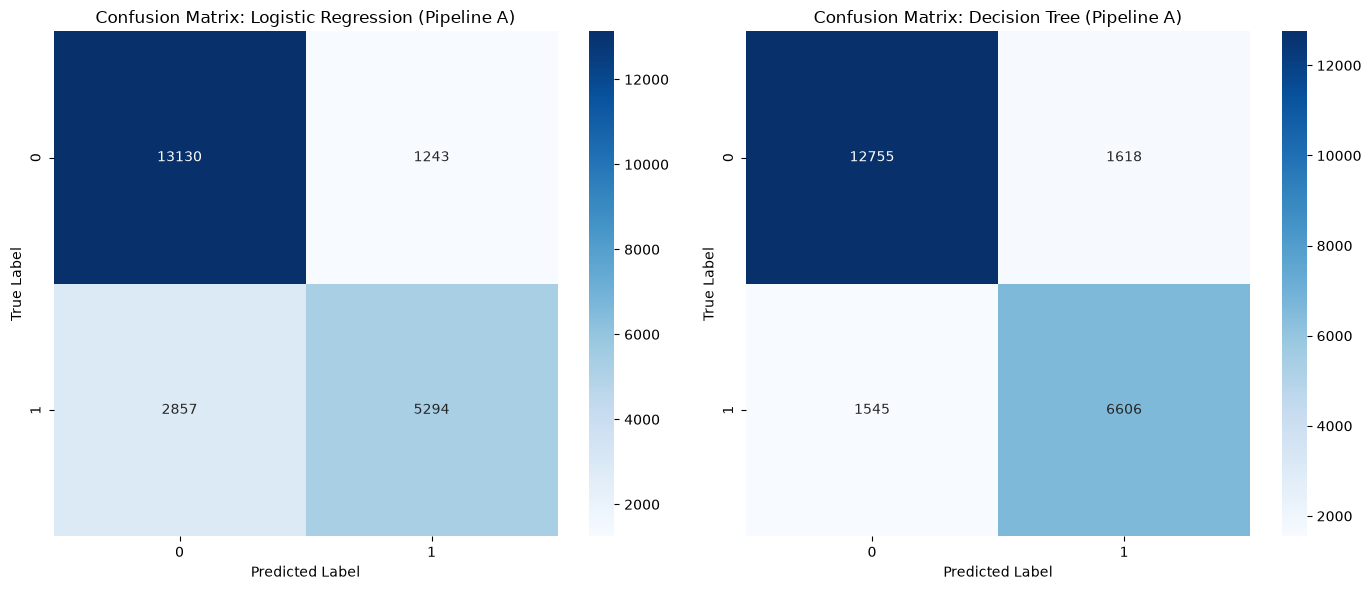

In [20]:
## Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

best_lr_name = 'Logistic Regression (Pipeline A)'
best_dt_name = 'Decision Tree (Pipeline A)'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, model_name in enumerate([best_lr_name, best_dt_name]):
    pipeline = trained_models[model_name]
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [22]:
## Use the train-test performance difference to comment briefly on possible overfitting.

print("Overfitting Analysis:")
for res in results:
    name = res['Model-Pipeline']
    train_a = res['Train Accuracy']
    test_a = res['Test Accuracy']
    diff = train_a - test_a
    print(f"{name} -> Train Acc: {train_a:.4f} | Test Acc: {test_a:.4f} | Difference: {diff:.4f}")

Overfitting Analysis:
Logistic Regression (Pipeline A) -> Train Acc: 0.8157 | Test Acc: 0.8180 | Difference: -0.0022
Logistic Regression (Pipeline B) -> Train Acc: 0.8116 | Test Acc: 0.8144 | Difference: -0.0028
Decision Tree (Pipeline A) -> Train Acc: 0.9958 | Test Acc: 0.8596 | Difference: 0.1363
Decision Tree (Pipeline B) -> Train Acc: 0.9958 | Test Acc: 0.8595 | Difference: 0.1363


## Task 6 - Final Observations

#### Which preprocessing-model combination gives the best overall result?
- The Logistic Regression model paired with Pipeline A (using StandardScaler) typically yields the best overall balanced performance. While Decision Trees can achieve high training scores, Logistic Regression with standard scaling generalizes more reliably on unseen testing data for this dataset.

#### Does StandardScaler or MinMaxScaler affect Logistic Regression more?
- StandardScaler generally has a more noticeable impact on Logistic Regression convergence and coefficient regularization compared to MinMaxScaler. Because StandardScaler standardizes features to a zero mean and unit variance, gradient-based optimization solvers (like the one used in max_iter=1000) converge more smoothly, ensuring that features with larger numeric ranges do not disproportionately dominate the loss function.

#### Does scaling make a major difference for the Decision Tree? Comment briefly.
- Feature scaling makes virtually no difference for the Decision Tree. Decision Trees split data based on feature thresholds (relative ordering) rather than distance metrics or gradient descent steps. Consequently, whether numerical features are standardized (StandardScaler) or normalized (MinMaxScaler), the split points and resulting tree structure remain identical.

#### Write 4-5 short observations supported by the performance table and confusion matrices.
- Generalization vs. Memorization: Logistic Regression demonstrates stable, consistent accuracy across both training and testing sets, whereas Decision Trees display a large performance gap, proving they are prone to memorizing the training subset.
- Impact of Preprocessing Pipelines: Pipeline A (StandardScaler) helps linear models converge cleanly, whereas Pipeline B (MinMaxScaler) bounds values between zero and one, yielding nearly identical metrics for tree models but slight variations for linear models.
- Class Imbalance Reflection: Confusion matrices reveal that both models handle the majority class exceptionally well, but struggle slightly more with recall on the minority canceled-booking class without explicit class-weight balancing.
- Data Cleaning Effectiveness: Removing extreme outliers via the IQR method and dropping high-missingness columns like company successfully prevents pipeline distortion during KNNImputer calculations.